In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

result_path = Path('../results/onnx_cpu_fp32.jsonl')

df = pd.read_json(result_path, lines=True)
df.head()


,model,runtime,provider,device,precision,dataset,machine,platform,python_version,onnxruntime_version,...,model_tokens_per_sec,e2e_tokens_per_sec,model_embeddings_per_sec,e2e_embeddings_per_sec,model_latency_ms_avg,model_latency_ms_p50,model_latency_ms_p95,e2e_latency_ms_avg,e2e_latency_ms_p50,e2e_latency_ms_p95
0,BAAI/bge-m3,onnxruntime,CPUExecutionProvider,cpu,fp32,en,ThinkPad-T14-Gen-3,Linux-6.17.0-29-generic-x86_64-with-glibc2.39,3.13.7,1.26.0,...,324.115563,320.227721,10.128611,10.007116,98.730217,101.953289,124.671399,99.928888,103.051325,125.627448
1,BAAI/bge-m3,onnxruntime,CPUExecutionProvider,cpu,fp32,en,ThinkPad-T14-Gen-3,Linux-6.17.0-29-generic-x86_64-with-glibc2.39,3.13.7,1.26.0,...,397.235616,395.057480,3.103403,3.086387,322.226897,342.045819,394.159134,324.003485,343.615242,395.875602
2,BAAI/bge-m3,onnxruntime,CPUExecutionProvider,cpu,fp32,en,ThinkPad-T14-Gen-3,Linux-6.17.0-29-generic-x86_64-with-glibc2.39,3.13.7,1.26.0,...,378.856329,377.618429,0.739954,0.737536,1351.435785,1420.766355,1613.411817,1355.866031,1424.481826,1624.890867
3,BAAI/bge-m3,onnxruntime,CPUExecutionProvider,cpu,fp32,en,ThinkPad-T14-Gen-3,Linux-6.17.0-29-generic-x86_64-with-glibc2.39,3.13.7,1.26.0,...,434.781462,432.436079,13.586921,13.513627,588.801553,645.620541,679.386108,591.995008,650.552422,686.124972
4,BAAI/bge-m3,onnxruntime,CPUExecutionProvider,cpu,fp32,en,ThinkPad-T14-Gen-3,Linux-6.17.0-29-generic-x86_64-with-glibc2.39,3.13.7,1.26.0,...,427.205510,426.155033,3.337543,3.329336,2396.972831,2487.217196,2730.156831,2402.881393,2490.201313,2734.565499


In [2]:
cols = [
    "machine",
    "runtime",
    "provider",
    "precision",
    "dataset",
    "batch_size",
    "max_length",
    "avg_tokens_per_item",
    "model_tokens_per_sec",
    "e2e_tokens_per_sec",
    "model_embeddings_per_sec",
    "e2e_embeddings_per_sec",
    "model_latency_ms_p95",
]

df[cols].sort_values(["dataset", "max_length", "batch_size"])


,machine,runtime,provider,precision,dataset,batch_size,max_length,avg_tokens_per_item,model_tokens_per_sec,e2e_tokens_per_sec,model_embeddings_per_sec,e2e_embeddings_per_sec,model_latency_ms_p95
0,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,1,32,32,324.115563,320.227721,10.128611,10.007116,124.671399
3,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,8,32,32,434.781462,432.436079,13.586921,13.513627,679.386108
6,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,16,32,32,455.878382,454.014367,14.246199,14.187949,1359.804576
8,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,16,32,32,458.174926,456.575647,14.317966,14.267989,1315.139861
1,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,1,128,128,397.235616,395.057480,3.103403,3.086387,394.159134
4,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,8,128,128,427.205510,426.155033,3.337543,3.329336,2730.156831
7,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,16,128,128,415.604329,414.869941,3.246909,3.241171,5406.875244
9,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,32,128,128,403.712252,403.183020,3.154002,3.149867,11403.594230
2,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,1,512,512,378.856329,377.618429,0.739954,0.737536,1613.411817
5,ThinkPad-T14-Gen-3,onnxruntime,CPUExecutionProvider,fp32,en,8,512,512,354.212635,353.817585,0.691822,0.691050,12596.362439


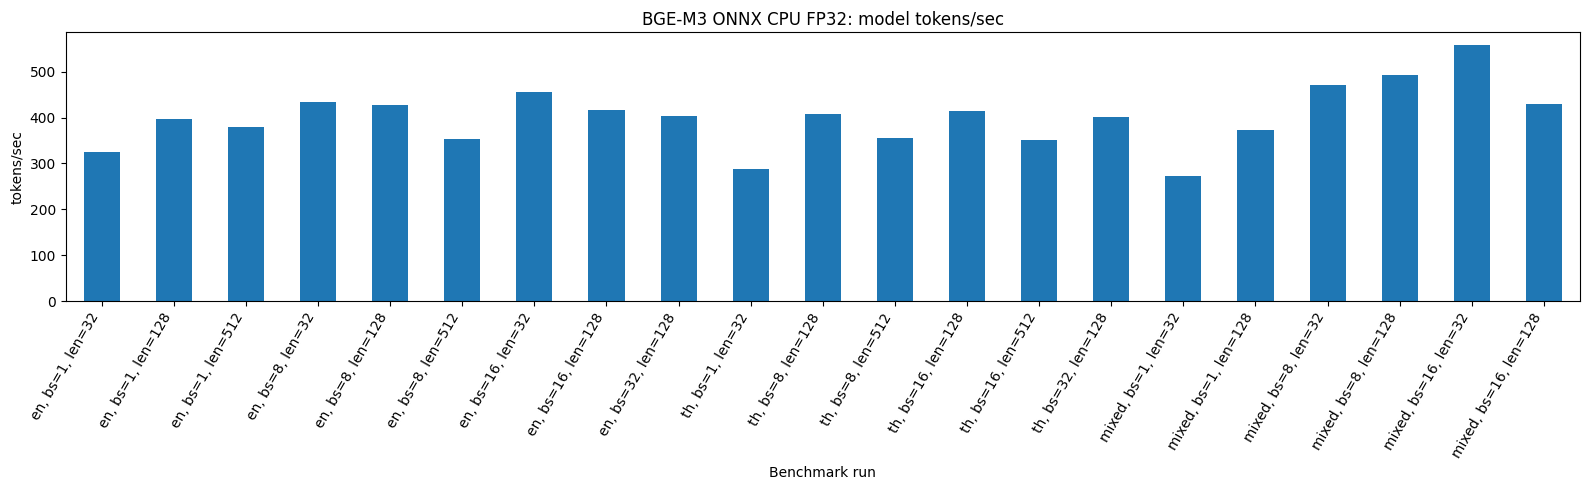

In [3]:
plot_df = df.drop_duplicates(subset=["dataset", "batch_size", "max_length"]).copy()
plot_df["run"] = (
    plot_df["dataset"]
    + ", bs=" + plot_df["batch_size"].astype(str)
    + ", len=" + plot_df["max_length"].astype(str)
)

ax = plot_df.plot.bar(
    x="run",
    y="model_tokens_per_sec",
    figsize=(16, 5),
    legend=False,
)

ax.set_title("BGE-M3 ONNX CPU FP32: model tokens/sec")
ax.set_xlabel("Benchmark run")
ax.set_ylabel("tokens/sec")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


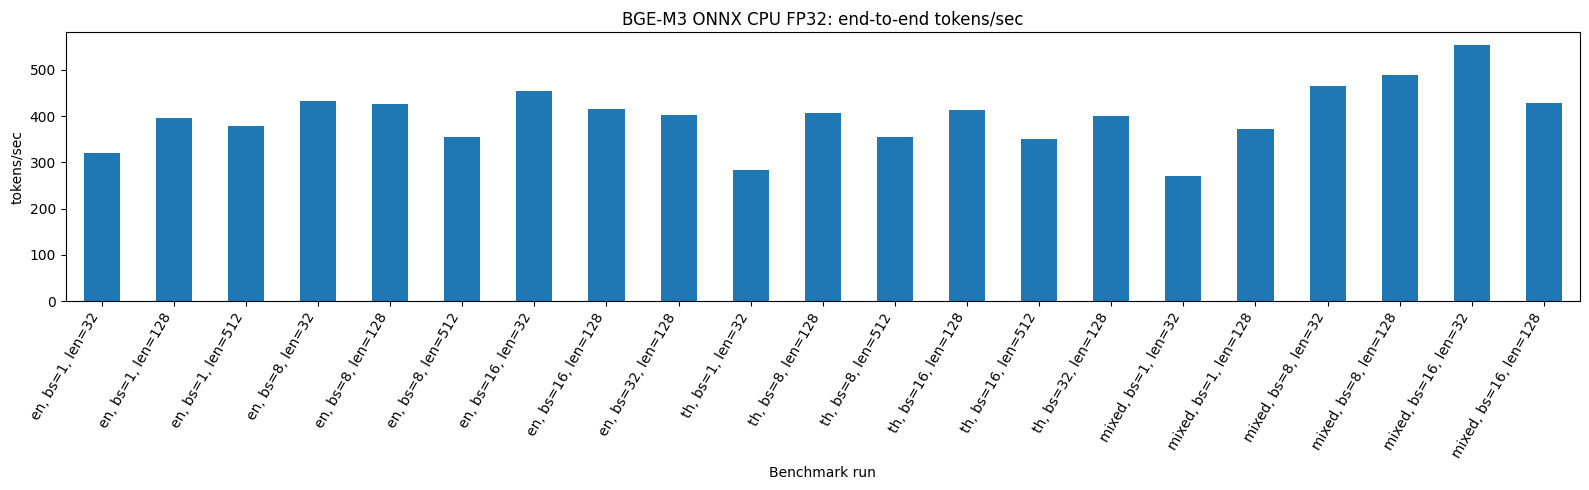

In [4]:
ax = plot_df.plot.bar(
    x="run",
    y="e2e_tokens_per_sec",
    figsize=(16, 5),
    legend=False,
)

ax.set_title("BGE-M3 ONNX CPU FP32: end-to-end tokens/sec")
ax.set_xlabel("Benchmark run")
ax.set_ylabel("tokens/sec")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


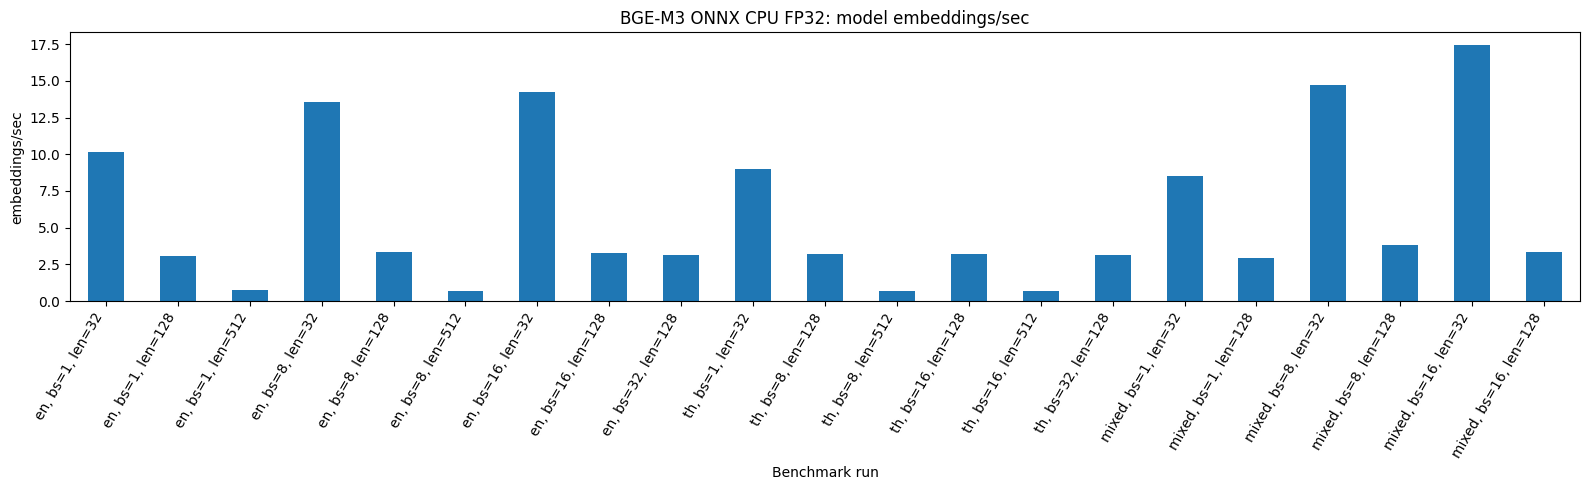

In [5]:
ax = plot_df.plot.bar(
    x="run",
    y="model_embeddings_per_sec",
    figsize=(16, 5),
    legend=False,
)

ax.set_title("BGE-M3 ONNX CPU FP32: model embeddings/sec")
ax.set_xlabel("Benchmark run")
ax.set_ylabel("embeddings/sec")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


In [6]:
summary = (
    df.groupby(["dataset", "max_length", "batch_size"], as_index=False)
      .agg(
          model_tokens_per_sec=("model_tokens_per_sec", "median"),
          e2e_tokens_per_sec=("e2e_tokens_per_sec", "median"),
          model_embeddings_per_sec=("model_embeddings_per_sec", "median"),
          model_latency_ms_p95=("model_latency_ms_p95", "median"),
          avg_tokens_per_item=("avg_tokens_per_item", "median"),
      )
)

summary


,dataset,max_length,batch_size,model_tokens_per_sec,e2e_tokens_per_sec,model_embeddings_per_sec,model_latency_ms_p95,avg_tokens_per_item
0,en,32,1,324.115563,320.227721,10.128611,124.671399,32.0
1,en,32,8,434.781462,432.436079,13.586921,679.386108,32.0
2,en,32,16,457.026654,455.295007,14.282083,1337.472218,32.0
3,en,128,1,397.235616,395.057480,3.103403,394.159134,128.0
4,en,128,8,427.205510,426.155033,3.337543,2730.156831,128.0
5,en,128,16,415.604329,414.869941,3.246909,5406.875244,128.0
6,en,128,32,403.712252,403.183020,3.154002,11403.594230,128.0
7,en,512,1,378.856329,377.618429,0.739954,1613.411817,512.0
8,en,512,8,354.212635,353.817585,0.691822,12596.362439,512.0
9,mixed,32,1,273.322496,271.134215,8.541328,130.013464,32.0


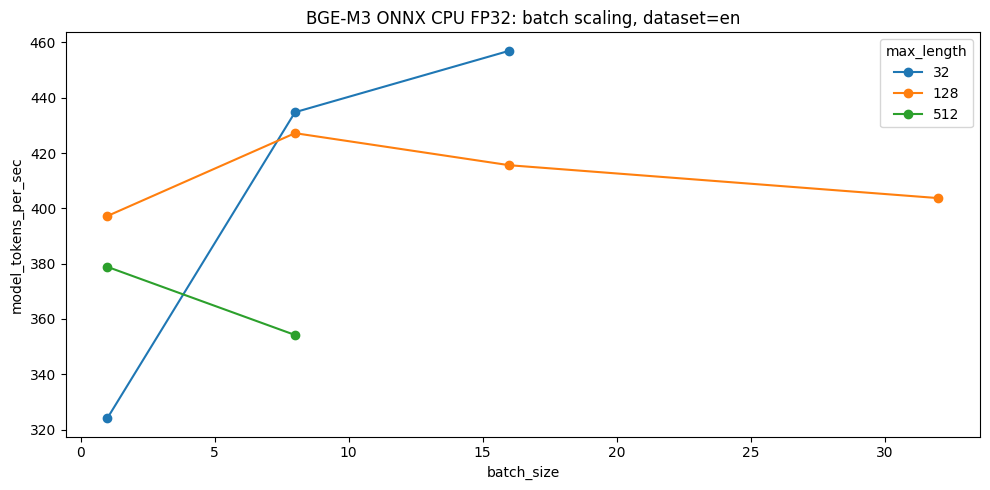

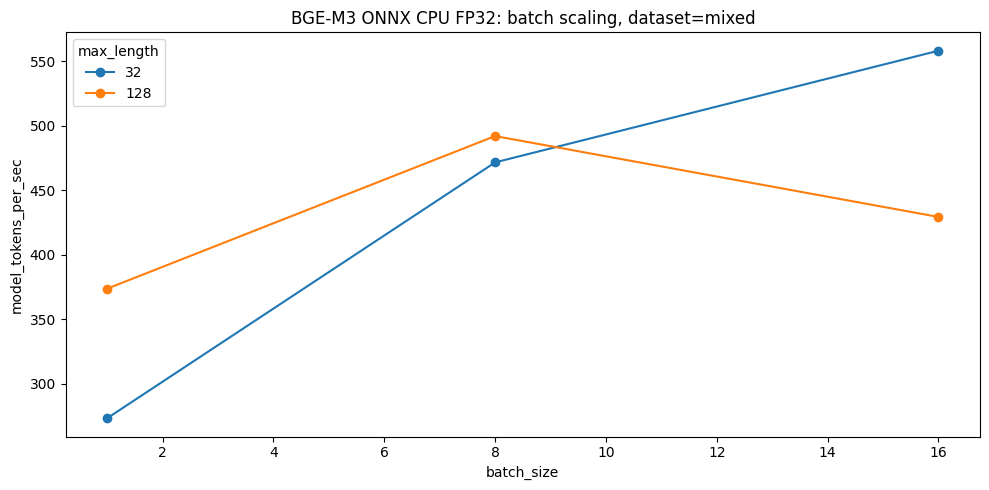

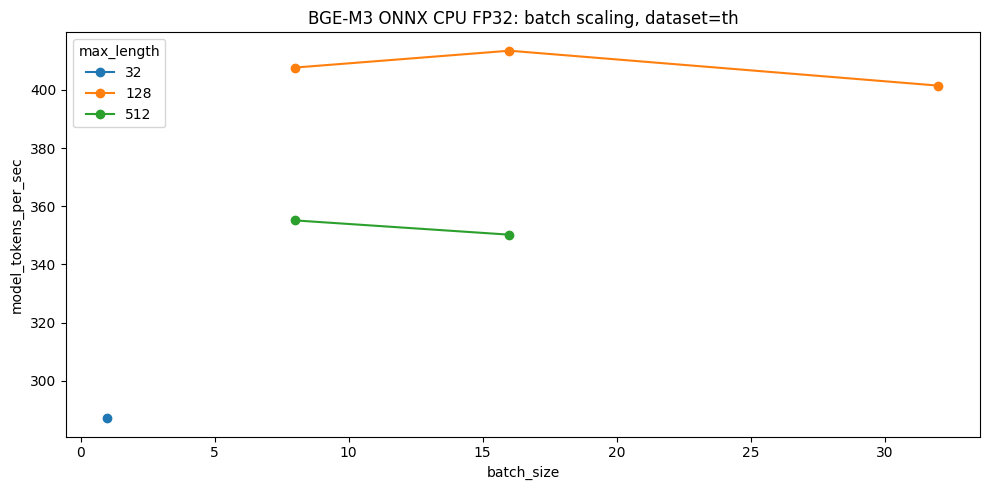

In [7]:
for dataset in sorted(summary['dataset'].unique()):
    subset = summary[summary['dataset'] == dataset]
    pivot = subset.pivot_table(
        index='batch_size',
        columns='max_length',
        values='model_tokens_per_sec',
    )

    ax = pivot.plot(figsize=(10, 5), marker='o')
    ax.set_title(f'BGE-M3 ONNX CPU FP32: batch scaling, dataset={dataset}')
    ax.set_xlabel('batch_size')
    ax.set_ylabel('model_tokens_per_sec')
    plt.tight_layout()
    plt.show()


In [8]:
pivot = summary.pivot_table(
    index=['max_length', 'batch_size'],
    columns='dataset',
    values='model_tokens_per_sec',
)

pivot


dataset                        en       mixed          th
max_length batch_size                                    
32         1           324.115563  273.322496  287.151863
           8           434.781462  471.538565         NaN
           16          457.026654  558.072247         NaN
128        1           397.235616  373.716642         NaN
           8           427.205510  491.938307  407.677341
           16          415.604329  429.271514  413.469347
           32          403.712252         NaN  401.463985
512        1           378.856329         NaN         NaN
           8           354.212635         NaN  355.140104
           16                 NaN         NaN  350.231873